<a href="https://colab.research.google.com/github/feridehmedovv200/OIBSIP/blob/main/DataAnalytics-Task4-SentimentAnalysis/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows loaded: 568,454
Dropped duplicate/empty reviews -> 393,579 unique reviews remain

Sentiment distribution:
            count  percent
sentiment                 
negative    57067     14.5
neutral     29754      7.6
positive   306758     77.9


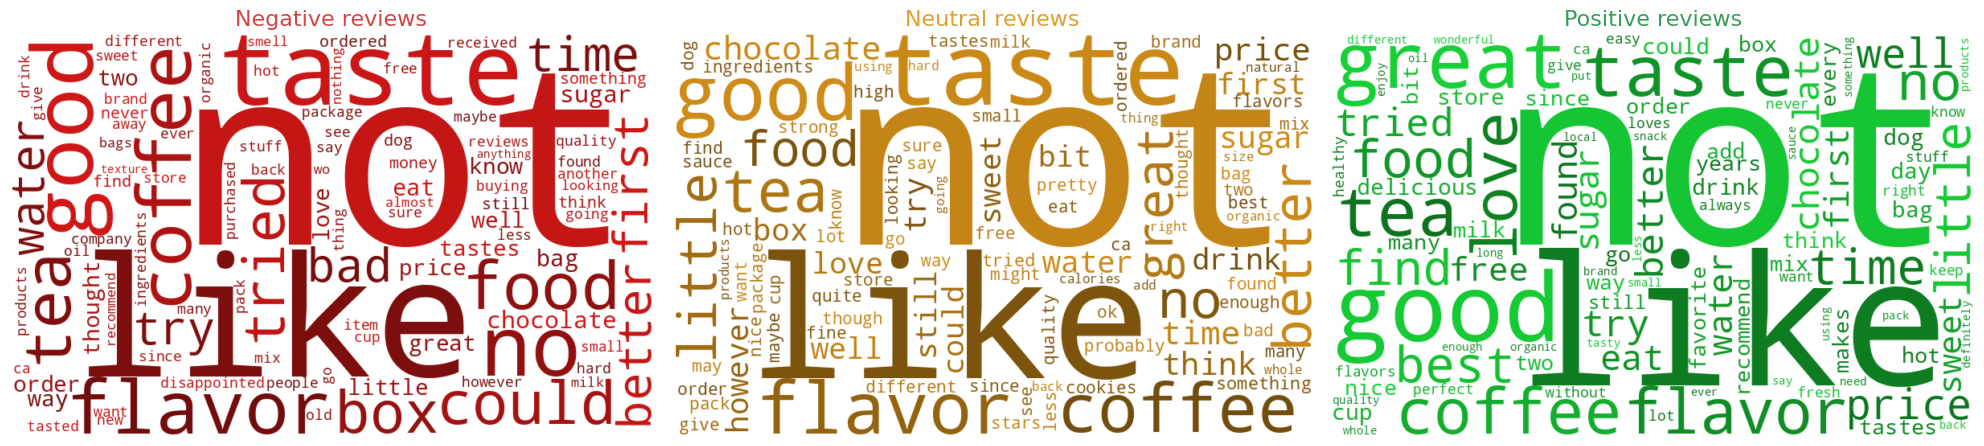

Naive Bayes | accuracy = 0.8020
              precision    recall  f1-score   support

    negative      0.599     0.746     0.665      2900
     neutral      0.265     0.437     0.330      1512
    positive      0.951     0.848     0.896     15588

    accuracy                          0.802     20000
   macro avg      0.605     0.677     0.630     20000
weighted avg      0.848     0.802     0.820     20000

Logistic Regression | accuracy = 0.8418
              precision    recall  f1-score   support

    negative      0.668     0.765     0.713      2900
     neutral      0.328     0.416     0.367      1512
    positive      0.948     0.897     0.922     15588

    accuracy                          0.842     20000
   macro avg      0.648     0.693     0.667     20000
weighted avg      0.860     0.842     0.850     20000

Model comparison on test set:
                     Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  \
Model                                                   

In [2]:
import re
import textwrap
from collections import Counter
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

nltk.download("stopwords", quiet=True)

# ---- Configuration -------------------------------------------------------
SEED = 42
DATA_PATH = "Reviews.csv"
SAMPLE_SIZE = 100_000          # Stratified sample; set to None for full dataset
LABELS = ["negative", "neutral", "positive"]
COLORS = {"negative": "#d64545", "neutral": "#e0a030", "positive": "#3a9d5d"}

sns.set_theme(style="whitegrid")

# ---- 1. Load Data ---------------------------------------------------------
raw = pd.read_csv(DATA_PATH, usecols=["Score", "Text"])
print(f"Rows loaded: {len(raw):,}")

df = raw.dropna(subset=["Text"]).drop_duplicates(subset="Text").copy()
print(f"Dropped duplicate/empty reviews -> {len(df):,} unique reviews remain")

SENTIMENT_MAP = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}
df["sentiment"] = df["Score"].map(SENTIMENT_MAP)

def class_distribution(frame):
    counts = frame["sentiment"].value_counts().reindex(LABELS)
    return pd.DataFrame({"count": counts, "percent": (counts / counts.sum() * 100).round(1)})

full_distribution = class_distribution(df)
print("\nSentiment distribution:")
print(full_distribution)

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df["sentiment"], random_state=SEED)
df = df.reset_index(drop=True)

# ---- 2. Preprocessing -----------------------------------------------------
STOP_WORDS = set(stopwords.words("english")) - {"no", "nor", "not"}   # Keep negations
tokenizer = RegexpTokenizer(r"[a-z]+")
stemmer = PorterStemmer()

@lru_cache(maxsize=None)
def stem(word):
    return stemmer.stem(word)

def clean_tokens(text):
    text = text.lower()
    text = text.replace("’", "'")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = tokenizer.tokenize(text)
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

tokens = df["Text"].apply(clean_tokens)
df["clean_text"] = tokens.apply(lambda words: " ".join(words))
df["stemmed_text"] = tokens.apply(lambda words: " ".join(stem(w) for w in words))

empty = df["stemmed_text"].str.len() == 0
df = df.loc[~empty].reset_index(drop=True)

# ---- 3. Word Clouds -------------------------------------------------------
GENERIC_WORDS = {"product", "one", "would", "get", "also", "really", "much", "even",
                 "use", "used", "got", "make", "made", "amazon", "bought", "buy"}

def make_color_func(hue):
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        return f"hsl({hue}, 80%, {random_state.randint(25, 45)}%)"
    return color_func

HUES = {"negative": 0, "neutral": 38, "positive": 130}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, label in zip(axes, LABELS):
    words = " ".join(df.loc[df["sentiment"] == label, "clean_text"]).split()
    freqs = Counter(w for w in words if w not in GENERIC_WORDS)
    cloud = WordCloud(width=800, height=500, background_color="white", max_words=100,
                      color_func=make_color_func(HUES[label]), random_state=SEED
                     ).generate_from_frequencies(freqs)
    ax.imshow(cloud.to_array(), interpolation="bilinear")
    ax.set_title(f"{label.capitalize()} reviews", fontsize=16, color=COLORS[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

# ---- 4. Train/Test Split & TF-IDF ----------------------------------------
train_df, test_df = train_test_split(df, test_size=0.20, stratify=df["sentiment"], random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=100_000, sublinear_tf=True)
X_train = tfidf.fit_transform(train_df["stemmed_text"])
X_test = tfidf.transform(test_df["stemmed_text"])
y_train = train_df["sentiment"].to_numpy()
y_test = test_df["sentiment"].to_numpy()

# ---- 5. Models & Tuning --------------------------------------------------
nb_search = GridSearchCV(
    MultinomialNB(fit_prior=False),
    param_grid={"alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]},
    scoring="f1_macro", cv=3, n_jobs=-1)
nb_search.fit(X_train, y_train)

lr_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=2000),
    param_grid={"C": [1, 3, 10]},
    scoring="f1_macro", cv=3, n_jobs=-1)
lr_search.fit(X_train, y_train)

models = {"Naive Bayes": nb_search.best_estimator_,
          "Logistic Regression": lr_search.best_estimator_}

# ---- 6. Evaluation -------------------------------------------------------
predictions = {}
rows = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_test, y_pred, labels=LABELS, average="macro", zero_division=0)
    _, _, f_wt, _ = precision_recall_fscore_support(y_test, y_pred, labels=LABELS, average="weighted", zero_division=0)
    rows.append({"Model": name, "Accuracy": acc, "Precision (macro)": p_mac,
                 "Recall (macro)": r_mac, "F1 (macro)": f_mac, "F1 (weighted)": f_wt})

    print("=" * 62)
    print(f"{name} | accuracy = {acc:.4f}")
    print("=" * 62)
    print(classification_report(y_test, y_pred, labels=LABELS, digits=3, zero_division=0))

summary = pd.DataFrame(rows).set_index("Model").round(4)
print("Model comparison on test set:")
print(summary)